# Feature Signal Analysis

Цель: посмотреть, какие анонимизированные сенсоры несут полезный одномерный сигнал для APS-positive класса, насколько missingness сам по себе информативен и есть ли сильная избыточность среди топ-признаков.


In [1]:
from pathlib import Path
import json
import os
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.cache' / 'matplotlib'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(PROJECT_ROOT))

from src.aps_failure.data import load_dataset, make_data_quality_report

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 80)

train_path = PROJECT_ROOT / 'data/raw/aps_failure_training_set.csv'
test_path = PROJECT_ROOT / 'data/raw/aps_failure_test_set.csv'
x_train, y_train = load_dataset(train_path)
x_test, y_test = load_dataset(test_path)
print(f'train: {x_train.shape}, test: {x_test.shape}')


train: (60000, 170), test: (16000, 170)


## Одномерная сигнальность числовых признаков

Для каждого признака считаем Average Precision в прямом и обратном направлении. Это быстрый ранжир: он не заменяет модель, но показывает, какие сенсоры уже по одному значению отделяют rare positive класс.


In [2]:
from sklearn.metrics import average_precision_score, roc_auc_score

rows = []
for column in x_train.columns:
    s = x_train[column]
    if s.nunique(dropna=True) < 2:
        continue
    filled = s.fillna(s.median())
    if filled.nunique(dropna=True) < 2:
        continue
    direct_ap = average_precision_score(y_train, filled)
    inverse_ap = average_precision_score(y_train, -filled)
    try:
        direct_auc = roc_auc_score(y_train, filled)
    except ValueError:
        direct_auc = np.nan
    rows.append(
        {
            'feature': column,
            'ap_best_direction': max(direct_ap, inverse_ap),
            'direction': 'high=>pos' if direct_ap >= inverse_ap else 'low=>pos',
            'roc_auc_direct': direct_auc,
            'missing_rate': s.isna().mean(),
            'median_neg': s[y_train == 0].median(),
            'median_pos': s[y_train == 1].median(),
            'p90_neg': s[y_train == 0].quantile(0.90),
            'p90_pos': s[y_train == 1].quantile(0.90),
        }
    )
univariate = pd.DataFrame(rows).sort_values('ap_best_direction', ascending=False)
univariate.head(30)


,feature,ap_best_direction,direction,roc_auc_direct,missing_rate,median_neg,median_pos,p90_neg,p90_pos
93,ci_000,0.458724,high=>pos,0.969133,0.005633,1824220.800,36076429.92,5753206.368,7.073930e+07
0,aa_000,0.443610,high=>pos,0.967447,0.000000,30416.000,584994.00,99096.000,1.270409e+06
70,bj_000,0.441218,high=>pos,0.946167,0.009817,149962.000,6044796.00,696004.000,1.695588e+07
162,ee_005,0.440697,high=>pos,0.866701,0.011183,183265.000,2717748.00,708232.400,1.076330e+07
80,bt_000,0.439762,high=>pos,0.965195,0.002783,30471.945,585163.41,99199.973,1.271192e+06
62,bb_000,0.431322,high=>pos,0.941813,0.010750,2319400.000,47370562.00,7480399.000,9.239418e+07
25,aq_000,0.428952,high=>pos,0.940930,0.009817,173044.000,4631158.00,728398.000,1.134015e+07
82,bv_000,0.428796,high=>pos,0.941333,0.011517,2317872.000,47163072.00,7449952.000,9.124671e+07
110,cq_000,0.428795,high=>pos,0.941333,0.011517,2317872.000,47163072.00,7449952.000,9.124671e+07
81,bu_000,0.428795,high=>pos,0.941333,0.011517,2317872.000,47163072.00,7449952.000,9.124671e+07


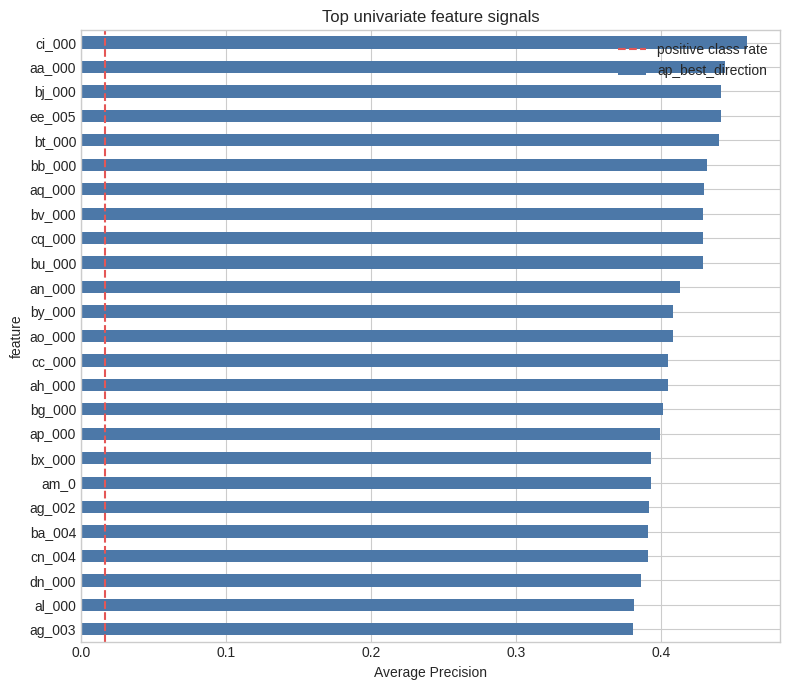

In [3]:
fig, ax = plt.subplots(figsize=(8, 7))
univariate.head(25).sort_values('ap_best_direction').plot(
    x='feature', y='ap_best_direction', kind='barh', ax=ax, legend=False, color='#4c78a8'
)
ax.axvline(y_train.mean(), color='#e45756', linestyle='--', label='positive class rate')
ax.set_title('Top univariate feature signals')
ax.set_xlabel('Average Precision')
ax.legend()
plt.tight_layout()


## Распределения топ-признаков по классам

Так удобнее увидеть, сигнал связан со сдвигом значений, хвостами распределения или большим количеством нулей. Используем `log1p`, потому что сенсорные значения сильно скошены.


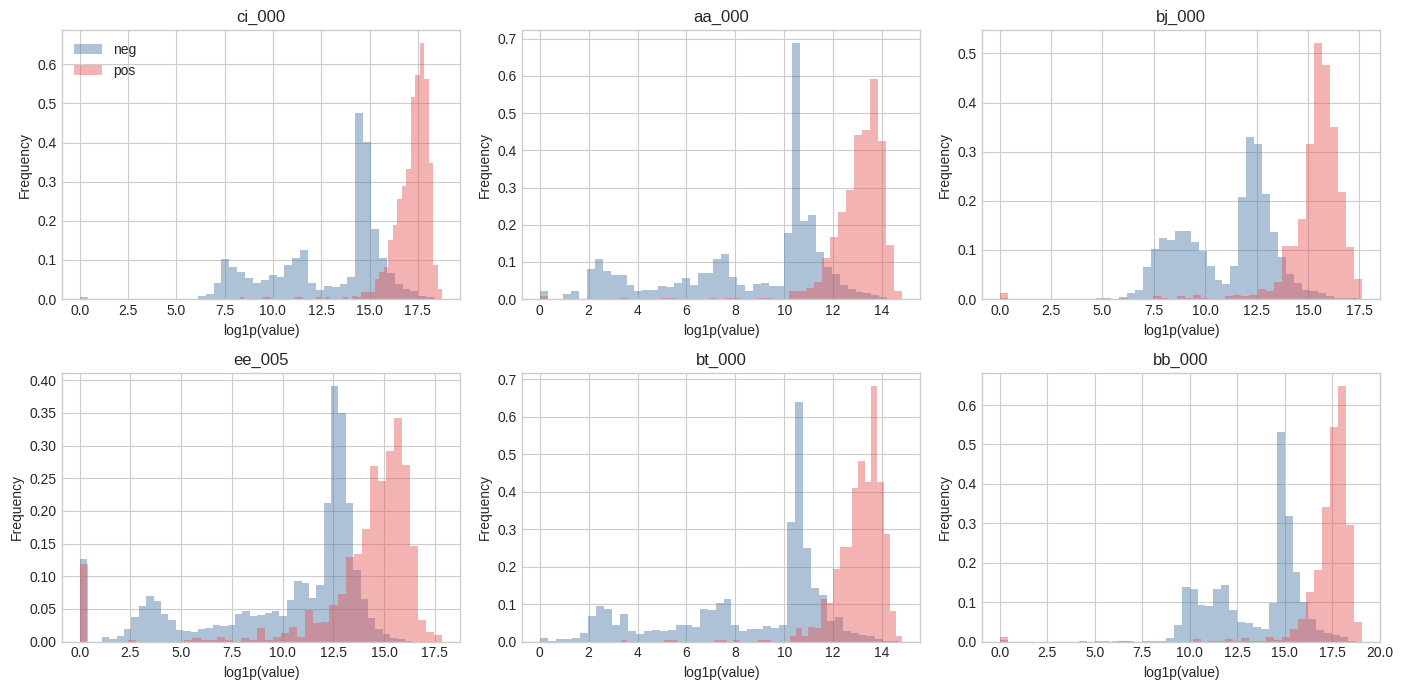

In [4]:
top_features = univariate.head(6)['feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, column in zip(axes.ravel(), top_features):
    for target_value, label, color in [(0, 'neg', '#4c78a8'), (1, 'pos', '#e45756')]:
        values = np.log1p(x_train.loc[y_train == target_value, column].dropna().clip(lower=0))
        values.sample(min(len(values), 10000), random_state=42).plot(
            kind='hist', bins=45, density=True, alpha=0.45, ax=ax, color=color, label=label
        )
    ax.set_title(column)
    ax.set_xlabel('log1p(value)')
axes[0, 0].legend()
plt.tight_layout()


## Missingness-as-signal

Некоторые датчики могут быть полезны не только значением, но и фактом отсутствия значения. Для этого сравниваем missing rate между классами и считаем AP по бинарному индикатору пропуска.


In [5]:
missing_signal_rows = []
for column in x_train.columns:
    indicator = x_train[column].isna().astype(int)
    if indicator.nunique() < 2:
        continue
    missing_neg = indicator[y_train == 0].mean()
    missing_pos = indicator[y_train == 1].mean()
    missing_signal_rows.append(
        {
            'feature': column,
            'missing_neg': missing_neg,
            'missing_pos': missing_pos,
            'missing_delta_pos_minus_neg': missing_pos - missing_neg,
            'missing_indicator_ap': average_precision_score(y_train, indicator),
        }
    )
missing_signal = pd.DataFrame(missing_signal_rows).sort_values(
    ['missing_indicator_ap', 'missing_delta_pos_minus_neg'], ascending=[False, False]
)
missing_signal.head(30)


,feature,missing_neg,missing_pos,missing_delta_pos_minus_neg,missing_indicator_ap
136,di_000,0.059017,0.524,0.464983,0.076475
137,dj_000,0.059034,0.524,0.464966,0.076457
138,dk_000,0.059034,0.524,0.464966,0.076457
154,eb_000,0.059034,0.524,0.464966,0.076457
133,df_000,0.059051,0.524,0.464949,0.076440
134,dg_000,0.059051,0.524,0.464949,0.076440
135,dh_000,0.059051,0.524,0.464949,0.076440
139,dl_000,0.059051,0.524,0.464949,0.076440
140,dm_000,0.059068,0.524,0.464932,0.076423
1,ac_000,0.048695,0.462,0.413305,0.072968


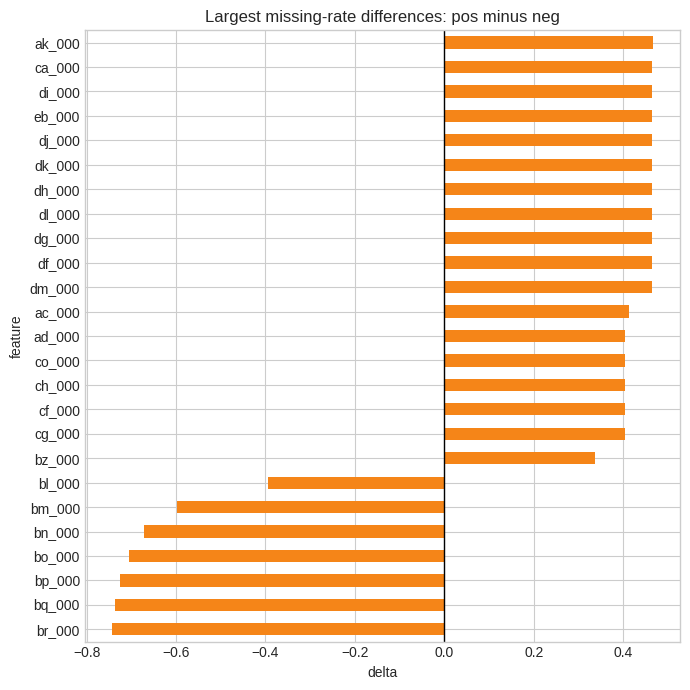

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
plot_df = missing_signal.reindex(missing_signal['missing_delta_pos_minus_neg'].abs().sort_values(ascending=False).index).head(25)
plot_df.sort_values('missing_delta_pos_minus_neg').plot(
    x='feature', y='missing_delta_pos_minus_neg', kind='barh', ax=ax, legend=False, color='#f58518'
)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Largest missing-rate differences: pos minus neg')
ax.set_xlabel('delta')
plt.tight_layout()


## Корреляции среди топ-сигналов

Если несколько сильных признаков почти дублируют друг друга, модель может быть устойчивой, но интерпретация feature importance станет менее однозначной.


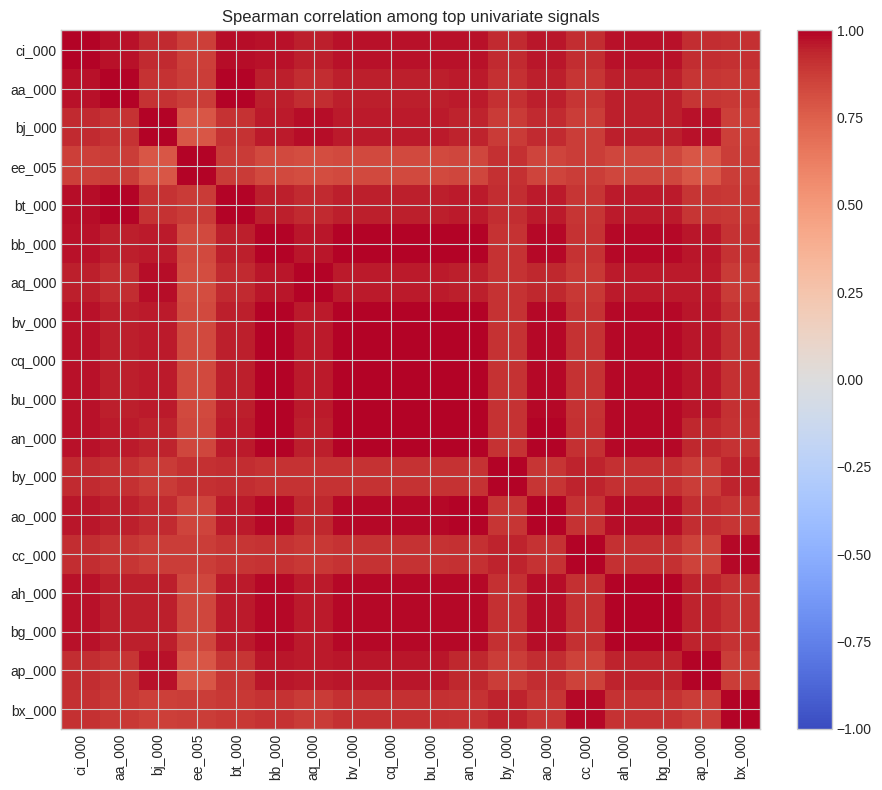

In [7]:
selected = univariate.head(18)['feature'].tolist()
sample = x_train[selected].sample(min(len(x_train), 20000), random_state=42).fillna(x_train[selected].median())
corr = sample.corr(method='spearman')
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(selected)), selected, rotation=90)
ax.set_yticks(range(len(selected)), selected)
ax.set_title('Spearman correlation among top univariate signals')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()


In [8]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = (
    upper.stack()
    .rename('spearman')
    .abs()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b'})
)
pairs


,feature_a,feature_b,spearman
0,bv_000,cq_000,1.000000
1,cq_000,bu_000,1.000000
2,bv_000,bu_000,1.000000
3,ah_000,bg_000,0.999185
4,bb_000,bv_000,0.998735
5,bb_000,cq_000,0.998735
6,bb_000,bu_000,0.998735
7,aa_000,bt_000,0.995386
8,an_000,ao_000,0.994933
9,bb_000,an_000,0.993506


## Сводный shortlist

Объединяем одномерный сигнал и сигнал пропусков. Эти признаки удобно использовать для устного объяснения модели и ручной проверки кейсов.


In [9]:
shortlist = (
    univariate.head(25)
    .merge(missing_signal[['feature', 'missing_delta_pos_minus_neg', 'missing_indicator_ap']], on='feature', how='left')
    .sort_values(['ap_best_direction', 'missing_indicator_ap'], ascending=False)
)
shortlist


,feature,ap_best_direction,direction,roc_auc_direct,missing_rate,median_neg,median_pos,p90_neg,p90_pos,missing_delta_pos_minus_neg,missing_indicator_ap
0,ci_000,0.458724,high=>pos,0.969133,0.005633,1824220.800,36076429.92,5753206.368,7.073930e+07,0.004441,0.016796
1,aa_000,0.443610,high=>pos,0.967447,0.000000,30416.000,584994.00,99096.000,1.270409e+06,NaN,NaN
2,bj_000,0.441218,high=>pos,0.946167,0.009817,149962.000,6044796.00,696004.000,1.695588e+07,0.030695,0.018716
3,ee_005,0.440697,high=>pos,0.866701,0.011183,183265.000,2717748.00,708232.400,1.076330e+07,-0.006288,0.016621
4,bt_000,0.439762,high=>pos,0.965195,0.002783,30471.945,585163.41,99199.973,1.271192e+06,0.008356,0.017208
5,bb_000,0.431322,high=>pos,0.941813,0.010750,2319400.000,47370562.00,7480399.000,9.239418e+07,0.030763,0.018590
6,aq_000,0.428952,high=>pos,0.940930,0.009817,173044.000,4631158.00,728398.000,1.134015e+07,0.030695,0.018716
7,bv_000,0.428796,high=>pos,0.941333,0.011517,2317872.000,47163072.00,7449952.000,9.124671e+07,0.031000,0.018519
8,cq_000,0.428795,high=>pos,0.941333,0.011517,2317872.000,47163072.00,7449952.000,9.124671e+07,0.031000,0.018519
9,bu_000,0.428795,high=>pos,0.941333,0.011517,2317872.000,47163072.00,7449952.000,9.124671e+07,0.031000,0.018519
